# GS33 — Step 1: Cell-type distribution analysis

Reads the CODA-labelled GeoJSONs (already available at `geojson_CODAclass`),
counts nuclei per cell type per slide, and exports summary CSVs used by Step 2.

> **Note:** Step 0 (`0_build_CODA_geojsons.ipynb`) is skipped for GS33 because
> the CODA-labelled GeoJSONs are already provided at `geojson_CODAclass`.

| Cell | Purpose |
|------|---------|
| 1 | Imports |
| **2** | **Parameters ← edit here** |
| 3 | Load & count |
| 4 | Statistics table |
| 5 | Plots |
| 6 | Export CSVs |

---
## 1 · Imports

In [1]:
import sys
from pathlib import Path
from collections import Counter
import json

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import display
from tqdm.auto import tqdm

sys.path.insert(0, str(Path.cwd()))
from dataset_utils import extract_cell_types_from_geojson, normalize_slide_stem

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (16, 8)
print("Imports OK")

Imports OK


---
## 2 · Parameters  ← edit here

In [ ]:
# ── Paths ──────────────────────────────────────────────────────────────────────────
GEOJSON_DIR = Path(r"\\kittyserverdw\Andre_kit\data\students\Diogo\data\fetal\GS33\geojson_CODAclass")
OUT_DIR     = Path(r"\\kittyserverdw\Andre_kit\data\students\Diogo\data\fetal\GS33\cellvit_training\cell_type_analysis")
OUT_DIR.mkdir(parents=True, exist_ok=True)

# ── Slide subsampling ─────────────────────────────────────────────────────────────
# GS33 has ~220 slides — use 1 every SLIDE_STRIDE to keep a manageable subset
SLIDE_STRIDE       = 5   # 220 slides → ~44 slides used

# ── Optional filters ─────────────────────────────────────────────────────────────
FILTER_SLIDE_IDS   = []
EXCLUDE_CELL_TYPES = ["Unassigned", "OutsideMask"]

print(f"GeoJSON dir : {GEOJSON_DIR}  (exists: {GEOJSON_DIR.exists()})")
print(f"Output dir  : {OUT_DIR}")
print(f"Slide stride: every {SLIDE_STRIDE}th slide")

---
## 3 · Load data

In [3]:
# ── Load all GeoJSON files ───────────────────────────────────────────────────────
gj_files = sorted(GEOJSON_DIR.glob("*.geojson"))
if not gj_files:
    raise FileNotFoundError(f"No GeoJSON files in {GEOJSON_DIR}")

total_slides = len(gj_files)
gj_files = gj_files[::SLIDE_STRIDE]
print(f"Slide subsampling: 1 every {SLIDE_STRIDE} → {len(gj_files)} / {total_slides} slides used")

if FILTER_SLIDE_IDS:
    gj_files = [f for f in gj_files if normalize_slide_stem(f) in FILTER_SLIDE_IDS]

print(f"Processing {len(gj_files)} slides")

rows = []
errors = []
for gj_path in tqdm(gj_files, desc="Extracting cell types"):
    slide_id = normalize_slide_stem(gj_path)
    counts = extract_cell_types_from_geojson(gj_path)
    if not counts:
        errors.append(gj_path.name)
        continue
    for cell_type, count in counts.items():
        if cell_type not in EXCLUDE_CELL_TYPES:
            rows.append({"slide_id": slide_id, "cell_type": cell_type, "count": count})

df = pd.DataFrame(rows)
if df.empty:
    raise ValueError("No cell data extracted — check GEOJSON_DIR and EXCLUDE_CELL_TYPES.")

total_cells = df["count"].sum()
n_slides    = df["slide_id"].nunique()
print(f"Slides: {n_slides}  |  Cell types: {df['cell_type'].nunique()}  |  Total cells: {total_cells:,}")
if errors:
    print(f"Skipped {len(errors)} files with no cells: {errors[:5]}")
display(df.head())

Slide subsampling: 1 every 10 → 22 / 220 slides used
Processing 22 slides


Extracting cell types:   0%|          | 0/22 [00:00<?, ?it/s]

Slides: 22  |  Cell types: 16  |  Total cells: 4,671,635


,slide_id,cell_type,count
0,RM_GS33_0001,collagen,28218
1,RM_GS33_0001,nontissue,2043
2,RM_GS33_0001,heart,1693
3,RM_GS33_0001,gi_track,1477
4,RM_GS33_0001,eye,274


---
## 4 · Statistics

In [4]:
# ── Overall cell-type distribution ────────────────────────────────────────────
cell_type_totals = df.groupby("cell_type")["count"].sum().sort_values(ascending=False)

print(f"{'Cell Type':<25} {'Count':>12} {'Percentage':>12}")
print("-" * 55)
for ct, cnt in cell_type_totals.items():
    print(f"{ct:<25} {cnt:>12,} {cnt/total_cells*100:>11.2f}%")

# ── Per-slide pivot table ─────────────────────────────────────────────────────
pivot_df = (
    df.pivot_table(index="slide_id", columns="cell_type", values="count",
                   fill_value=0, aggfunc="sum")
)
pivot_df["TOTAL"] = pivot_df.sum(axis=1)
pivot_df = pivot_df.sort_values("TOTAL", ascending=False)
print(f"\nPivot table: {pivot_df.shape[0]} slides × {pivot_df.shape[1]-1} cell types")
display(pivot_df.head(10))

Cell Type                        Count   Percentage
-------------------------------------------------------
collagen                     2,609,357       55.86%
brain_+_spinal_cord          1,310,643       28.06%
bone_skull                     270,504        5.79%
liver                          251,835        5.39%
gi_track                        62,821        1.34%
nontissue                       49,490        1.06%
heart                           47,427        1.02%
kidney                          26,790        0.57%
eye                             17,759        0.38%
ear                             13,527        0.29%
lungs                            5,243        0.11%
thyroid                          3,026        0.06%
bladder                          2,715        0.06%
spleen                             260        0.01%
thymus                             150        0.00%
pancreas                            88        0.00%

Pivot table: 22 slides × 16 cell types


cell_type,bladder,bone_skull,brain_+_spinal_cord,collagen,ear,eye,gi_track,heart,kidney,liver,lungs,nontissue,pancreas,spleen,thymus,thyroid,TOTAL
slide_id,,,,,,,,,,,,,,,,,
RM_GS33_0431,203,16676,160114,176116,834,526,5637,8980,258,9638,22,3778,0,80,31,299,383192
RM_GS33_0361,235,24069,91043,152911,167,0,4288,10128,8456,21344,2906,4875,11,3,0,9,320445
RM_GS33_0341,119,22758,86738,156542,117,0,3594,7178,6750,23349,693,4064,0,0,12,315,312229
RM_GS33_0301,76,11440,102914,151784,15,0,3049,3654,225,25235,15,2503,0,0,28,571,301509
RM_GS33_0321,35,11075,80693,144713,131,0,2688,4567,1650,21891,0,2439,0,0,0,442,270324
RM_GS33_0541,51,21221,23094,177965,1621,2784,5443,4173,8863,13954,1587,3051,77,176,3,283,264346
RM_GS33_0261,50,9540,65379,144607,110,0,4875,2019,0,23942,0,2061,0,0,0,203,252786
RM_GS33_0281,22,9496,75164,131504,36,0,2310,2477,0,22190,0,2174,0,0,0,437,245810
RM_GS33_0181,227,9351,73056,135332,980,18,4632,120,56,14692,0,2156,0,0,0,35,240655


---
## 5 · Plots

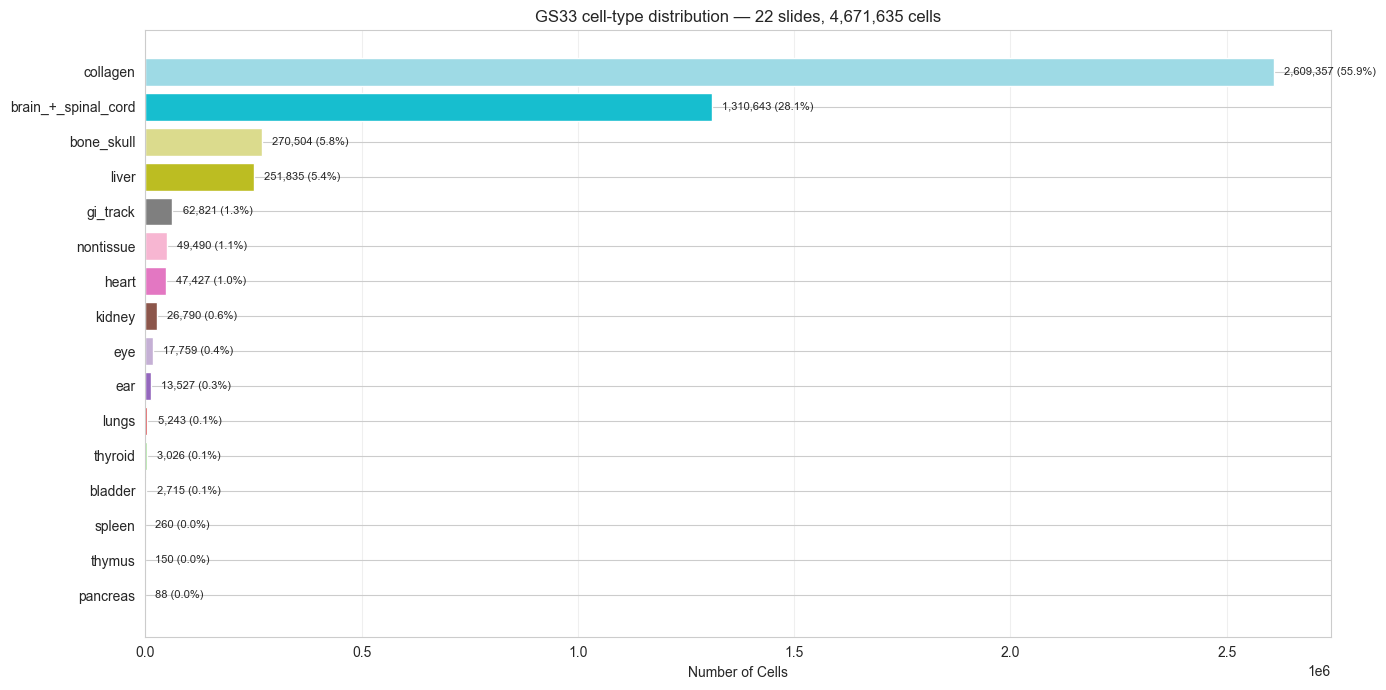

Saved: \\kittyserverdw\Andre_kit\data\students\Diogo\data\fetal\GS33\cellvit_training\cell_type_analysis\01_cell_type_distribution_overall.png


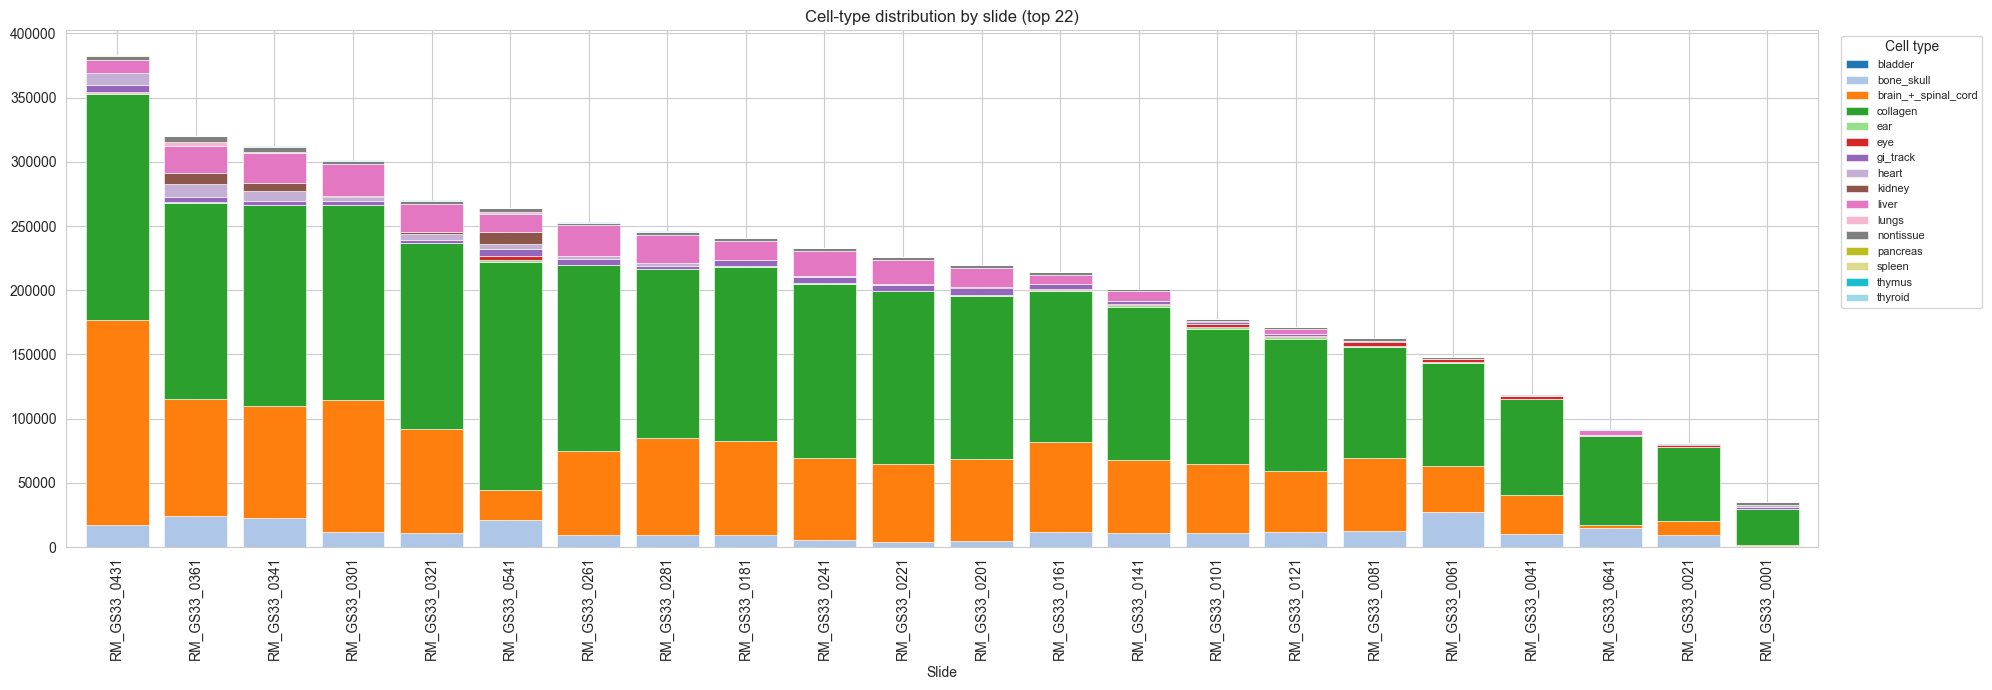

Saved: \\kittyserverdw\Andre_kit\data\students\Diogo\data\fetal\GS33\cellvit_training\cell_type_analysis\02_cell_type_distribution_per_slide.png


In [5]:
# ── Overall bar chart ─────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(14, 7))
ct_sorted = cell_type_totals.sort_values(ascending=True)
colors    = plt.cm.tab20(np.linspace(0, 1, len(ct_sorted)))
ax.barh(ct_sorted.index, ct_sorted.values, color=colors)
for i, (ct, cnt) in enumerate(ct_sorted.items()):
    ax.text(cnt + total_cells * 0.005, i, f"{cnt:,} ({cnt/total_cells*100:.1f}%)", va="center", fontsize=8)
ax.set_xlabel("Number of Cells")
ax.set_title(f"GS33 cell-type distribution — {n_slides} slides, {total_cells:,} cells")
ax.grid(axis="x", alpha=0.3)
plt.tight_layout()
plt.savefig(OUT_DIR / "01_cell_type_distribution_overall.png", dpi=300, bbox_inches="tight")
plt.show()
print(f"Saved: {OUT_DIR / '01_cell_type_distribution_overall.png'}")

# ── Per-slide stacked bar (top 40 slides) ───────────────────────────────────────────
fig, ax = plt.subplots(figsize=(20, 7))
top_n    = min(40, len(pivot_df))
plot_df  = pivot_df.drop(columns=["TOTAL"]).head(top_n)
plot_df.plot(kind="bar", stacked=True, ax=ax, colormap="tab20", width=0.8,
             edgecolor="white", linewidth=0.4)
ax.set_title(f"Cell-type distribution by slide (top {top_n})")
ax.set_xlabel("Slide")
ax.legend(title="Cell type", bbox_to_anchor=(1.01, 1), loc="upper left", fontsize=8)
plt.xticks(rotation=90)
plt.tight_layout()
plt.savefig(OUT_DIR / "02_cell_type_distribution_per_slide.png", dpi=300, bbox_inches="tight")
plt.show()
print(f"Saved: {OUT_DIR / '02_cell_type_distribution_per_slide.png'}")

---
## 6 · Export CSVs

In [6]:
# ── Export CSVs ────────────────────────────────────────────────────────────────────
pivot_df.to_csv(OUT_DIR / "cell_counts_per_slide.csv")
df.to_csv(OUT_DIR / "cell_counts_detailed.csv", index=False)

summary = pd.DataFrame({
    "cell_type":   cell_type_totals.index,
    "total_count": cell_type_totals.values,
    "percentage":  (cell_type_totals.values / total_cells * 100).round(2),
}).reset_index(drop=True)
summary.to_csv(OUT_DIR / "cell_type_summary.csv", index=False)

slide_totals = df.groupby("slide_id")["count"].sum().sort_values(ascending=False)
slide_summary = pd.DataFrame({"slide_id": slide_totals.index, "total_cells": slide_totals.values})
slide_summary.to_csv(OUT_DIR / "slide_summary.csv", index=False)

print("Saved:")
for f in ["cell_counts_per_slide.csv", "cell_counts_detailed.csv",
          "cell_type_summary.csv", "slide_summary.csv"]:
    print(f"  {OUT_DIR / f}")

print(f"\nTop 5 cell types:")
for i, (ct, cnt) in enumerate(cell_type_totals.head(5).items(), 1):
    print(f"  {i}. {ct}: {cnt:,} ({cnt/total_cells*100:.2f}%)")

print("\n>>> Review the class distribution above before running notebook 2.")
print(">>> Adjust DOWNSAMPLE_WEIGHTS and OVERSAMPLE_TARGETS in notebook 2 if GS33 differs from GS55.")

Saved:
  \\kittyserverdw\Andre_kit\data\students\Diogo\data\fetal\GS33\cellvit_training\cell_type_analysis\cell_counts_per_slide.csv
  \\kittyserverdw\Andre_kit\data\students\Diogo\data\fetal\GS33\cellvit_training\cell_type_analysis\cell_counts_detailed.csv
  \\kittyserverdw\Andre_kit\data\students\Diogo\data\fetal\GS33\cellvit_training\cell_type_analysis\cell_type_summary.csv
  \\kittyserverdw\Andre_kit\data\students\Diogo\data\fetal\GS33\cellvit_training\cell_type_analysis\slide_summary.csv

Top 5 cell types:
  1. collagen: 2,609,357 (55.86%)
  2. brain_+_spinal_cord: 1,310,643 (28.06%)
  3. bone_skull: 270,504 (5.79%)
  4. liver: 251,835 (5.39%)
  5. gi_track: 62,821 (1.34%)

>>> Review the class distribution above before running notebook 2.
>>> Adjust DOWNSAMPLE_WEIGHTS and OVERSAMPLE_TARGETS in notebook 2 if GS33 differs from GS55.
